# 06 - Final Model Evaluation

## Objective

This notebook evaluates one configuration already fixed in Notebook 05:

`XGBoost Full -> Sigmoid calibration -> calibrated_probability -> threshold 0.08 -> alert_flag`

Model family, features, hyperparameters, calibration method, and provisional threshold are not selected or adjusted here. The May-August 2026 period is a temporal holdout used for final comparative evaluation, although it was inspected during earlier Logistic Regression baseline development. It is therefore not described as strictly blind; genuinely blind evidence is reserved for future prospective observations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import yaml

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
def find_repo_file(relative_path):
    current_path = Path.cwd().resolve()
    for repository_candidate in (current_path, *current_path.parents):
        candidate_path = repository_candidate / relative_path
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(f"Could not find repository file: {relative_path}")

data_path = find_repo_file(Path("data") / "processed" / "dataset_features.csv")
threshold_config_path = find_repo_file(Path("configs") / "thresholds.yaml")

df = pd.read_csv(data_path, parse_dates=["Fecha"])
with threshold_config_path.open("r", encoding="utf-8") as config_file:
    threshold_config = yaml.safe_load(config_file)

print("Dataset shape:", df.shape)
print("Date range:", df["Fecha"].min(), "->", df["Fecha"].max())
print("Threshold config:", threshold_config_path)

Dataset shape: (33971, 156)
Date range: 2025-01-02 00:00:00 -> 2026-08-25 00:00:00
Threshold config: C:\Users\heresc\Documents\fdp-escriba-2026\configs\thresholds.yaml


In [3]:
calibration_start = pd.Timestamp("2026-02-01")
threshold_selection_start = pd.Timestamp("2026-04-01")
holdout_start = pd.Timestamp("2026-05-01")

model_train_df = df.loc[df["Fecha"] < calibration_start].copy()
calibration_fit_df = df.loc[
    (df["Fecha"] >= calibration_start)
    & (df["Fecha"] < threshold_selection_start)
].copy()
threshold_selection_df = df.loc[
    (df["Fecha"] >= threshold_selection_start)
    & (df["Fecha"] < holdout_start)
].copy()
holdout_df = df.loc[df["Fecha"] >= holdout_start].copy()

assert model_train_df["Fecha"].max() < calibration_fit_df["Fecha"].min()
assert calibration_fit_df["Fecha"].max() < threshold_selection_df["Fecha"].min()
assert threshold_selection_df["Fecha"].max() < holdout_df["Fecha"].min()

partition_summary = pd.DataFrame([
    {"partition": "Model training", "role": "fit XGBoost Full", "data": model_train_df},
    {"partition": "Calibration fit", "role": "fit locked Sigmoid", "data": calibration_fit_df},
    {"partition": "Threshold selection", "role": "historical selection in Notebook 05", "data": threshold_selection_df},
    {"partition": "Temporal holdout", "role": "evaluation only", "data": holdout_df},
])
partition_summary = pd.DataFrame({
    "partition": partition_summary["partition"],
    "role": partition_summary["role"],
    "start": [part["Fecha"].min() for part in partition_summary["data"]],
    "end": [part["Fecha"].max() for part in partition_summary["data"]],
    "rows": [len(part) for part in partition_summary["data"]],
    "md": [int(part["missed_delivery"].sum()) for part in partition_summary["data"]],
    "md_rate": [part["missed_delivery"].mean() for part in partition_summary["data"]],
})
display(partition_summary.round(4))

C:\Users\heresc\AppData\Local\Temp\ipykernel_26492\394852010.py:35: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(partition_summary.round(4))


,partition,role,start,end,rows,md,md_rate
0,Model training,fit XGBoost Full,2025-01-02,2026-01-31,22342,2036,0.0911
1,Calibration fit,fit locked Sigmoid,2026-02-02,2026-03-31,4131,191,0.0462
2,Threshold selection,historical selection in Notebook 05,2026-04-01,2026-04-30,1801,128,0.0711
3,Temporal holdout,evaluation only,2026-05-04,2026-08-25,5697,360,0.0632


## Locked Pipeline Reconstruction

Notebook 06 reproduces the configuration decided in Notebook 05. XGBoost Full and its preprocessing are fitted only on observations before February 2026. The already selected sigmoid method is then fitted using February-March scores. The threshold `0.08`, selected using April in Notebook 05, is read from configuration rather than re-optimised. No May-August row enters model fitting, calibration fitting, or threshold selection.

In [4]:
target_col = "missed_delivery"
date_col = "Fecha"
categorical_cols = ["Grupo_raiz", "customer", "uat", "destination"]
feature_cols = [col for col in df.columns if col not in [target_col, date_col]]
numeric_cols = [col for col in feature_cols if col not in categorical_cols]

X_model_train = model_train_df[feature_cols]
y_model_train = model_train_df[target_col]
X_calibration_fit = calibration_fit_df[feature_cols]
y_calibration_fit = calibration_fit_df[target_col]
X_holdout = holdout_df[feature_cols]
y_holdout = holdout_df[target_col]

print("Original predictors:", len(feature_cols))
print("Numeric predictors:", len(numeric_cols))
print("Categorical predictors:", len(categorical_cols))

Original predictors: 154
Numeric predictors: 150
Categorical predictors: 4


In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
final_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols),
])

X_model_train_transformed = final_preprocessor.fit_transform(X_model_train)
X_calibration_fit_transformed = final_preprocessor.transform(X_calibration_fit)
X_holdout_transformed = final_preprocessor.transform(X_holdout)

final_feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in final_preprocessor.get_feature_names_out()
]

scale_pos_weight_final = (
    (y_model_train == 0).sum() / (y_model_train == 1).sum()
)
final_xgb_full = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_final,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
final_xgb_full.fit(X_model_train_transformed, y_model_train)

print("XGBoost Full fitted on locked training window.")
print("Transformed predictors:", len(final_feature_names))
print("scale_pos_weight:", round(scale_pos_weight_final, 4))

XGBoost Full fitted on locked training window.
Transformed predictors: 467
scale_pos_weight: 9.9735


In [6]:
def score_to_logit(score):
    score = np.asarray(score, dtype=float)
    score = np.clip(score, 1e-6, 1 - 1e-6)
    return np.log(score / (1 - score)).reshape(-1, 1)

raw_score_calibration_fit = final_xgb_full.predict_proba(
    X_calibration_fit_transformed
)[:, 1]
selected_calibrator = LogisticRegression(random_state=42)
selected_calibrator.fit(
    score_to_logit(raw_score_calibration_fit),
    y_calibration_fit,
)

selected_calibration_method = "Sigmoid"
threshold = float(threshold_config["selected_candidate"]["threshold"])

assert threshold_config["model_name"] == "xgboost_full"
assert threshold_config["calibration_method"].lower() == "sigmoid"
assert threshold_config["score_field"] == "calibrated_probability"
assert np.isclose(threshold, 0.08)

print("Locked calibrator:", selected_calibration_method)
print("Locked provisional threshold:", threshold)
print("No holdout observation used for fitting.")

Locked calibrator: Sigmoid
Locked provisional threshold: 0.08
No holdout observation used for fitting.


## Temporal Holdout Evaluation

The May-August 2026 temporal holdout is used exclusively for comparative and descriptive evaluation of the locked pipeline. Although this period was inspected during earlier Logistic Regression baseline development, no holdout result below is used to modify XGBoost Full, sigmoid calibration, the feature set, hyperparameters, or threshold 0.08. Prospective future data will provide the first strictly blind evaluation.

In [7]:
raw_score = final_xgb_full.predict_proba(X_holdout_transformed)[:, 1]
calibrated_probability = selected_calibrator.predict_proba(
    score_to_logit(raw_score)
)[:, 1]
alert_flag = (calibrated_probability >= threshold).astype(int)

holdout_predictions = holdout_df[[
    "Fecha", "Grupo_raiz", "customer", "uat",
    "destination", target_col
]].copy()
holdout_predictions["raw_score"] = raw_score
holdout_predictions["calibrated_probability"] = calibrated_probability
holdout_predictions["threshold"] = threshold
holdout_predictions["alert_flag"] = alert_flag

assert np.all((calibrated_probability >= 0) & (calibrated_probability <= 1))
assert holdout_predictions["Fecha"].min() >= holdout_start

display(holdout_predictions.head())

,Fecha,Grupo_raiz,customer,uat,destination,missed_delivery,raw_score,calibrated_probability,threshold,alert_flag
3,2026-05-05,10030T,098A41,UATE2,098A41D01,0,0.099961,0.025808,0.08,0
4,2026-05-07,10030T,098A41,UATE2,098A41D01,0,0.109966,0.028325,0.08,0
5,2026-05-13,10030T,098A41,UATE2,098A41D01,0,0.066996,0.017595,0.08,0
6,2026-05-19,10030T,098A41,UATE2,098A41D01,0,0.187963,0.048717,0.08,0
7,2026-05-27,10030T,098A41,UATE2,098A41D01,0,0.114844,0.029559,0.08,0


In [8]:
score_summary = pd.DataFrame({
    "raw_score": pd.Series(raw_score).describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    ),
    "calibrated_probability": pd.Series(calibrated_probability).describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    ),
})
display(score_summary.round(6))

,raw_score,calibrated_probability
count,5697.000000,5697.000000
mean,0.186043,0.060292
std,0.196253,0.085229
min,0.002073,0.000744
10%,0.020202,0.005810
25%,0.046052,0.012385
50%,0.115792,0.029799
75%,0.234279,0.061725
90%,0.503614,0.161737
max,0.935060,0.676048


In [9]:
precision_final = precision_score(y_holdout, alert_flag, zero_division=0)
recall_final = recall_score(y_holdout, alert_flag, zero_division=0)
f1_final = f1_score(y_holdout, alert_flag, zero_division=0)
pr_auc_final = average_precision_score(y_holdout, calibrated_probability)
roc_auc_final = roc_auc_score(y_holdout, calibrated_probability)
brier_final = brier_score_loss(y_holdout, calibrated_probability)

tn_final, fp_final, fn_final, tp_final = confusion_matrix(
    y_holdout, alert_flag, labels=[0, 1]
).ravel()
alert_count_final = int(alert_flag.sum())
alert_rate_final = float(alert_flag.mean())
operating_days_final = int(holdout_df["Fecha"].dt.normalize().nunique())
alerts_per_operating_day_final = alert_count_final / operating_days_final

discrimination_metrics = pd.DataFrame([{
    "model": "XGBoost Full + Sigmoid",
    "pr_auc": pr_auc_final,
    "roc_auc": roc_auc_final,
}])
threshold_metrics = pd.DataFrame([{
    "threshold": threshold,
    "precision": precision_final,
    "recall": recall_final,
    "f1": f1_final,
    "TP": int(tp_final),
    "FP": int(fp_final),
    "FN": int(fn_final),
    "TN": int(tn_final),
    "alert_count": alert_count_final,
    "alert_rate": alert_rate_final,
    "operating_days": operating_days_final,
    "alerts_per_operating_day": alerts_per_operating_day_final,
}])
calibration_metric = pd.DataFrame([{
    "calibration_method": selected_calibration_method,
    "brier_score": brier_final,
}])

print("A) Discrimination metrics (threshold-independent)")
display(discrimination_metrics.round(6))
print("B) Threshold-dependent and operational metrics")
display(threshold_metrics.round(6))
print("C) Descriptive probability calibration metric")
display(calibration_metric.round(6))
print(classification_report(y_holdout, alert_flag, digits=4))

A) Discrimination metrics (threshold-independent)


,model,pr_auc,roc_auc
0,XGBoost Full + Sigmoid,0.286937,0.85164


B) Threshold-dependent and operational metrics


,threshold,precision,recall,f1,TP,FP,FN,TN,alert_count,alert_rate,operating_days,alerts_per_operating_day
0,0.08,0.232781,0.741667,0.354346,267,880,93,4457,1147,0.201334,69,16.623188


C) Descriptive probability calibration metric


,calibration_method,brier_score
0,Sigmoid,0.051393


              precision    recall  f1-score   support

           0     0.9796    0.8351    0.9016      5337
           1     0.2328    0.7417    0.3543       360

    accuracy                         0.8292      5697
   macro avg     0.6062    0.7884    0.6280      5697
weighted avg     0.9324    0.8292    0.8670      5697



### Final Holdout Results

PR-AUC (**0.2869**) and ROC-AUC (**0.8516**) describe discrimination and ranking independently of threshold 0.08. The locked operating rule obtains **23.28% Precision**, **74.17% Recall**, and **0.3543 F1-score**. It identifies 267 of 360 MD events, with 880 FP, 93 FN, and 4,457 TN.

The rule generates **1,147 alerts**, an Alert Rate of **20.13%**, and **16.62 alerts per operating day** across 69 active dates. This exceeds the provisional April capacity assumption of 15 alerts per active day on average. The difference is an operational limitation to validate, not a reason to retune the threshold on the holdout.

The calibrated-probability Brier Score is **0.05139**. It is a descriptive holdout result and is not used to reconsider sigmoid calibration.

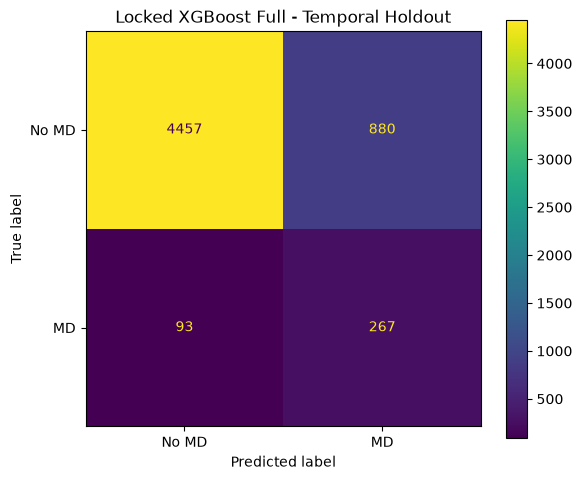

In [10]:
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn_final, fp_final], [fn_final, tp_final]]),
    display_labels=["No MD", "MD"],
)
fig, ax = plt.subplots(figsize=(6, 5))
confusion_display.plot(ax=ax, values_format="d")
ax.set_title("Locked XGBoost Full - Temporal Holdout")
fig.tight_layout()
plt.show()

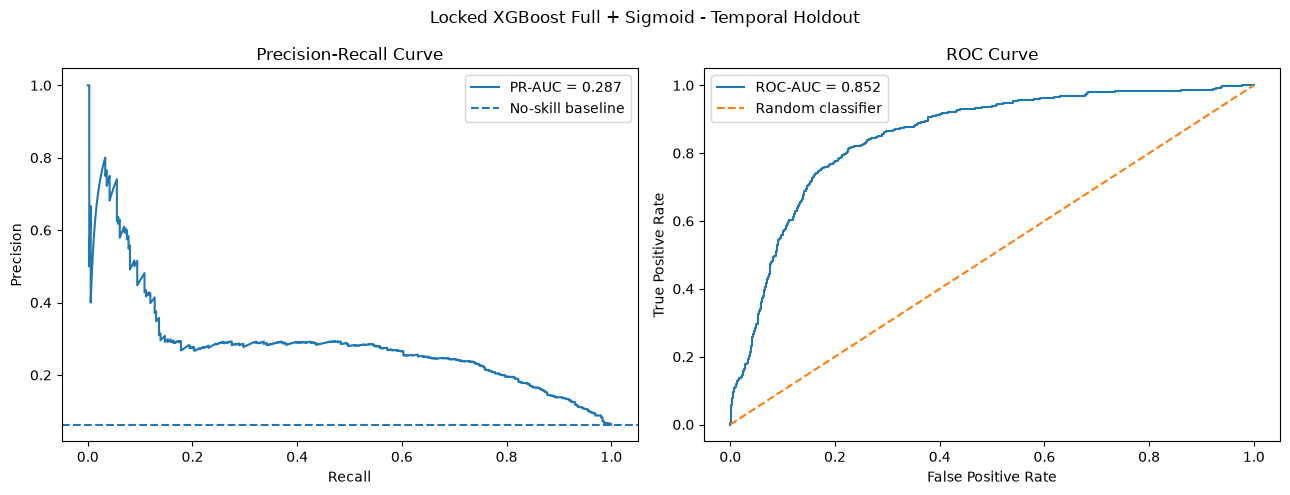

In [11]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_holdout, calibrated_probability
)
fpr_curve, tpr_curve, _ = roc_curve(y_holdout, calibrated_probability)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc_final:.3f}")
axes[0].axhline(y_holdout.mean(), linestyle="--", label="No-skill baseline")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[0].legend()

axes[1].plot(fpr_curve, tpr_curve, label=f"ROC-AUC = {roc_auc_final:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
axes[1].legend()

fig.suptitle("Locked XGBoost Full + Sigmoid - Temporal Holdout")
fig.tight_layout()
plt.show()

In [12]:
final_importance = pd.DataFrame({
    "feature": final_feature_names,
    "importance": final_xgb_full.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
display(final_importance.head(20))

,feature,importance
0,destination_432008D01,0.028620
1,destination_091A07D01,0.023816
2,uat_UATZ2,0.023057
3,destination_097E30D01,0.021720
4,customer_073D61,0.015821
5,customer_091A07,0.014956
6,week_of_year,0.012730
7,customer_097E30,0.012060
8,uat_UATM19,0.011586
9,customer_432005,0.010456


## SHAP Interpretability

SHAP is retained to explain how features contribute to the **raw XGBoost model output**. It does not explain the sigmoid transformation as a separate model, and it does not establish causality. Positive SHAP values push the raw model output towards Missed Delivery; negative values push it towards no Missed Delivery. A fixed sample keeps the analysis reproducible and proportionate.

In [13]:
shap_sample_size = min(2000, X_holdout_transformed.shape[0])
shap_rng = np.random.default_rng(42)
shap_sample_index = shap_rng.choice(
    X_holdout_transformed.shape[0], size=shap_sample_size, replace=False
)
X_holdout_shap = X_holdout_transformed[shap_sample_index]
if hasattr(X_holdout_shap, "toarray"):
    X_holdout_shap = X_holdout_shap.toarray()
else:
    X_holdout_shap = np.asarray(X_holdout_shap)

shap_explainer = shap.TreeExplainer(final_xgb_full)
shap_values = shap_explainer(X_holdout_shap)
shap_values.feature_names = final_feature_names
print("SHAP sample:", X_holdout_shap.shape)

SHAP sample: (2000, 467)


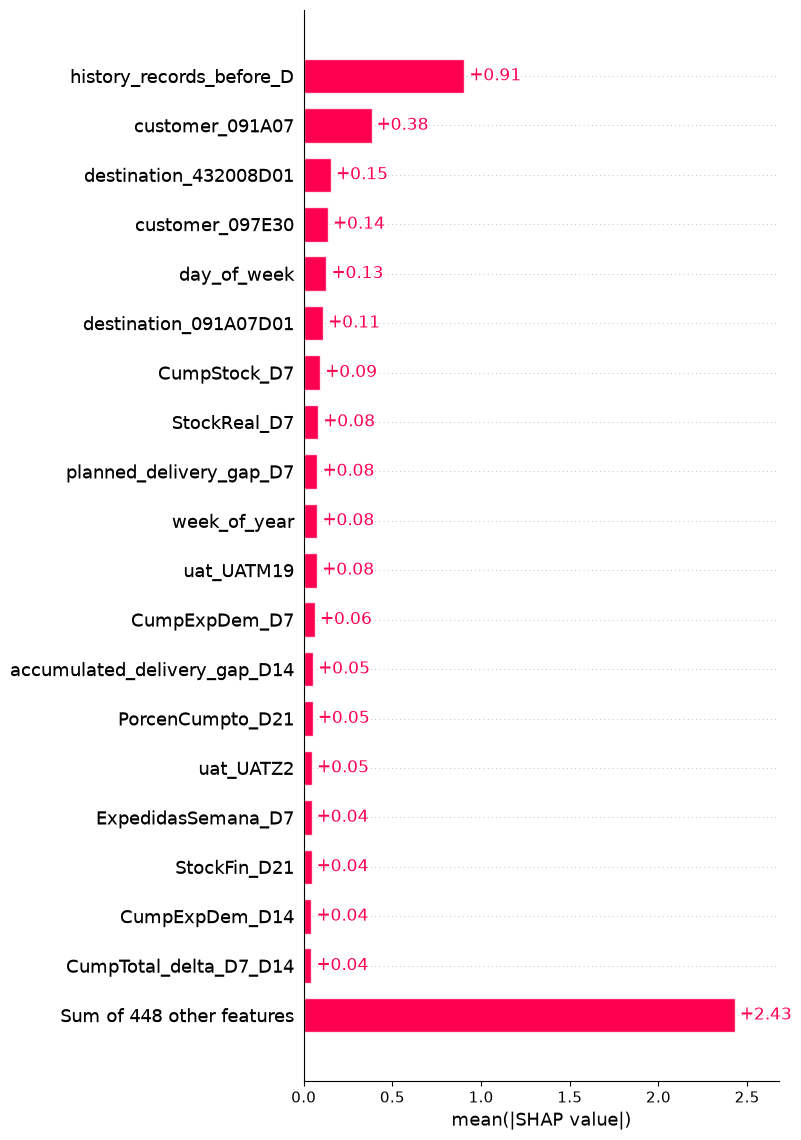

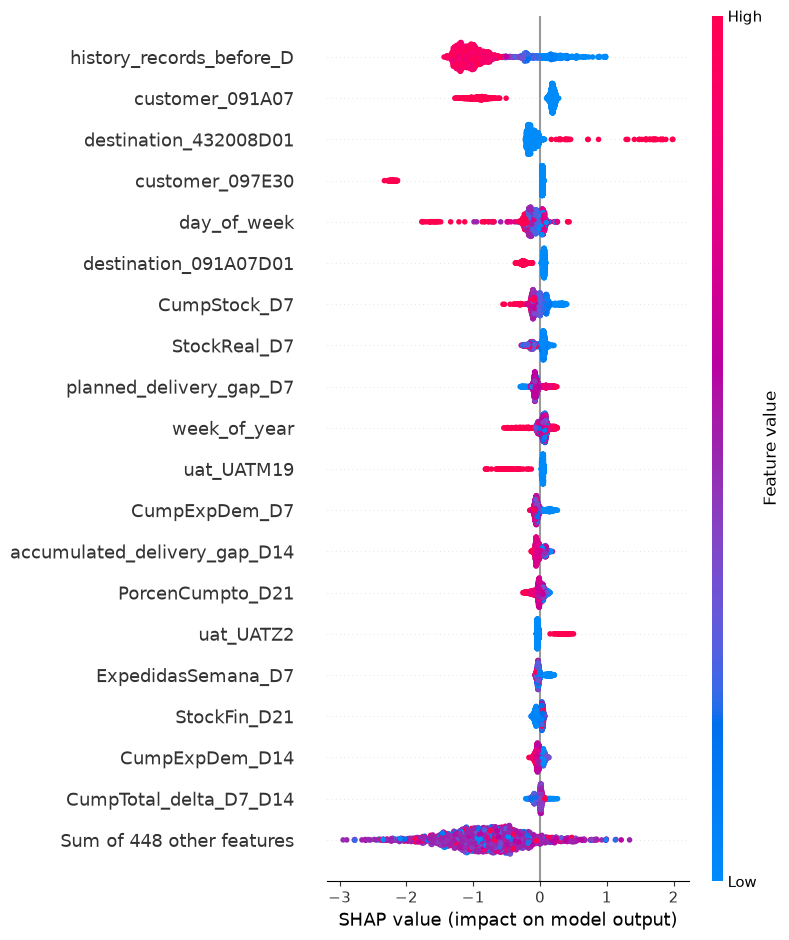

In [14]:
shap.plots.bar(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.show()

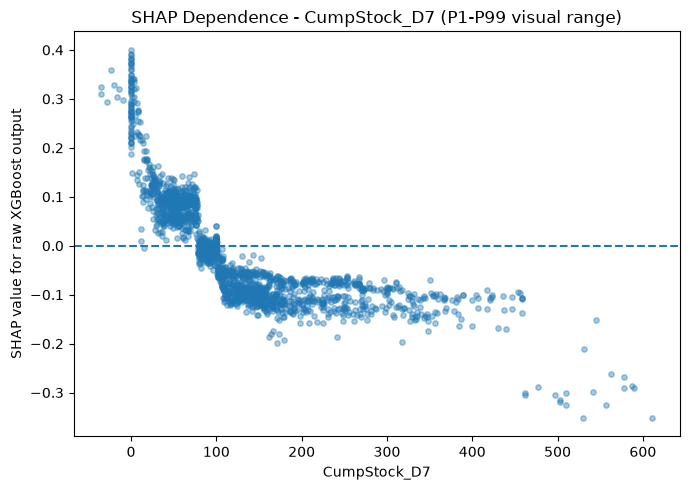

CumpStock_D7: P1=-35.00, P99=611.24


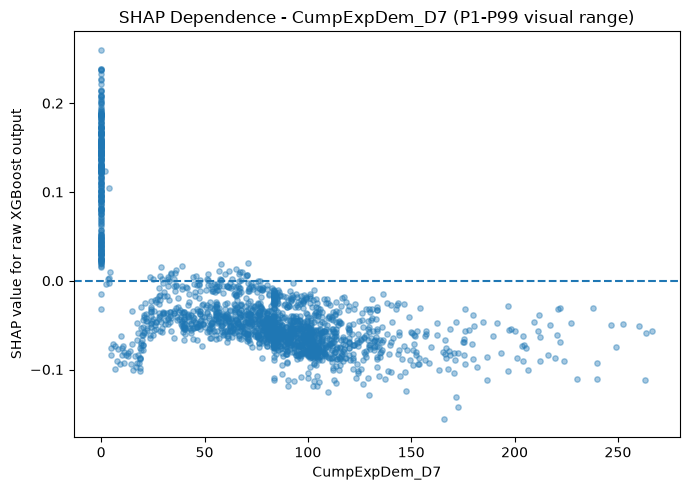

CumpExpDem_D7: P1=0.00, P99=266.78


In [15]:
for feature in ["CumpStock_D7", "CumpExpDem_D7"]:
    feature_index = final_feature_names.index(feature)
    feature_values = X_holdout_shap[:, feature_index]
    feature_shap = shap_values.values[:, feature_index]
    lower, upper = np.nanpercentile(feature_values, [1, 99])
    visual_mask = (feature_values >= lower) & (feature_values <= upper)

    plt.figure(figsize=(7, 5))
    plt.scatter(
        feature_values[visual_mask], feature_shap[visual_mask],
        alpha=0.4, s=15,
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel(feature)
    plt.ylabel("SHAP value for raw XGBoost output")
    plt.title(f"SHAP Dependence - {feature} (P1-P99 visual range)")
    plt.tight_layout()
    plt.show()
    print(f"{feature}: P1={lower:.2f}, P99={upper:.2f}")

### SHAP Interpretation

The strongest global SHAP driver remains `history_records_before_D`, followed by contextual variables including `customer_091A07`, `destination_432008D01`, and `customer_097E30`. Calendar context also contributes through `day_of_week` and `week_of_year`.

Recent operational conditions remain visible: `CumpStock_D7`, `StockReal_D7`, `planned_delivery_gap_D7`, and `CumpExpDem_D7` appear among the leading global contributions. Lower `CumpStock_D7` and `CumpExpDem_D7` values generally push the raw XGBoost output towards Missed Delivery. Extreme ratios can reflect small denominators, so the dependence plots restrict only their visual range. These are predictive associations learned by XGBoost, not causal effects or deterministic operational rules.

## False-Negative Analysis

False Negatives are defined using the locked rule `calibrated_probability < 0.08`. The final holdout contains **93 FN** and **267 TP**. They are analysed only to document limitations and possible future data improvements. No result in this section is used to change the threshold.

In [16]:
test_analysis = holdout_df.copy()
test_analysis["raw_score"] = raw_score
test_analysis["calibrated_probability"] = calibrated_probability
test_analysis["alert_flag"] = alert_flag

test_analysis["prediction_type"] = np.select(
    [
        (test_analysis[target_col] == 1) & (test_analysis["alert_flag"] == 1),
        (test_analysis[target_col] == 1) & (test_analysis["alert_flag"] == 0),
        (test_analysis[target_col] == 0) & (test_analysis["alert_flag"] == 1),
        (test_analysis[target_col] == 0) & (test_analysis["alert_flag"] == 0),
    ],
    ["TP", "FN", "FP", "TN"],
    default="Unknown",
)

error_analysis_features = [
    "CumpStock_D7", "CumpExpDem_D7", "StockReal_D7",
    "planned_delivery_gap_D7", "history_records_before_D",
    "available_lag_count",
]
tp_fn_summary = (
    test_analysis.loc[
        test_analysis["prediction_type"].isin(["TP", "FN"])
    ]
    .groupby("prediction_type")[error_analysis_features]
    .median()
    .T
)

print(test_analysis["prediction_type"].value_counts())
display(tp_fn_summary)

prediction_type
TN    4457
FP     880
TP     267
FN      93
Name: count, dtype: int64


prediction_type,FN,TP
CumpStock_D7,89.000000,47.950001
CumpExpDem_D7,72.699997,57.600000
StockReal_D7,640.000000,360.000000
planned_delivery_gap_D7,2.000000,0.000000
history_records_before_D,499.000000,479.000000
available_lag_count,4.000000,4.000000


In [17]:
md_probability_summary = (
    test_analysis.loc[
        test_analysis["prediction_type"].isin(["TP", "FN"])
    ]
    .groupby("prediction_type")[[
        "raw_score", "calibrated_probability"
    ]]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
)
display(md_probability_summary.round(6))

fn_probabilities = test_analysis.loc[
    test_analysis["prediction_type"] == "FN",
    "calibrated_probability",
]
fn_proximity_records = []
for lower_bound in [0.02, 0.04, 0.06, 0.07]:
    fn_count = int((fn_probabilities >= lower_bound).sum())
    fn_proximity_records.append({
        "calibrated_probability_at_least": lower_bound,
        "false_negatives": fn_count,
        "fraction_of_false_negatives": fn_count / len(fn_probabilities),
    })
fn_threshold_proximity = pd.DataFrame(fn_proximity_records)
display(fn_threshold_proximity.round(4))

raw_score                                                    \
                    count      mean       std       min       10%       25%   
prediction_type                                                               
FN                   93.0  0.164829  0.073292  0.008162  0.061396  0.113143   
TP                  267.0  0.569132  0.167546  0.295043  0.343662  0.439764   

                                                         \
                      50%       75%       90%       max   
prediction_type                                           
FN               0.171983  0.224342  0.256102  0.291791   
TP               0.558063  0.667378  0.829817  0.935060   

                calibrated_probability                                \
                                 count      mean       std       min   
prediction_type                                                        
FN                                93.0  0.043190  0.019571  0.002556   
TP                               267.0  0.227091  0.132964  0.080162   

                                                                             
                      10%       25%       50%       75%       90%       max  
prediction_type                                                              
FN               0.016205  0.029128  0.044403  0.058866  0.068151  0.079130  
TP               0.096295  0.132889  0.190168  0.262445  0.441237  0.676048

,calibrated_probability_at_least,false_negatives,fraction_of_false_negatives
0,0.02,81,0.8710
1,0.04,51,0.5484
2,0.06,20,0.2151
3,0.07,7,0.0753


### False-Negative Interpretation

The TP/FN comparison confirms that undetected MD events tend to show healthier D-7 conditions. Median `CumpStock_D7` is **89.0** for FN versus **47.95** for TP; median `CumpExpDem_D7` is **72.70** versus **57.60**, and median `StockReal_D7` is **640** versus **360**. Historical coverage is similar, with four available lags in both groups.

Only **7 of 93 FN (7.53%)** have `calibrated_probability >= 0.07`, placing them within 0.01 of the threshold. Most are therefore not borderline cases. Additional reliable pre-event information, rather than retrospective threshold adjustment, is the appropriate future improvement path.

## Final Conclusion

XGBoost Full, sigmoid calibration, and provisional threshold 0.08 were all selected before this holdout evaluation. May-August 2026 is used exclusively for comparative and descriptive reporting; no model, calibrator, feature, hyperparameter, or threshold adjustment is made from its results.

**The final evaluated configuration is XGBoost Full with sigmoid probability calibration and a provisional operational threshold of 0.08.**

On the temporal holdout, this configuration obtains Precision **23.28%**, Recall **74.17%**, F1 **0.3543**, PR-AUC **0.2869**, ROC-AUC **0.8516**, and Brier Score **0.05139**. It generates 1,147 alerts, equivalent to 20.13% of observations and 16.62 alerts per operating day.

The pipeline should be interpreted as an early-warning prioritisation tool rather than a deterministic classifier. SHAP and False Negative analyses document predictive behaviour and limitations without implying causality or reopening configuration decisions. The first strictly blind validation is reserved for future prospective data.

## Limitations and Next Step

The temporal holdout was inspected during early Logistic Regression development, the dataset represents one industrial environment, class imbalance limits Precision at high Recall, and several MD events are not preceded by visible deterioration in the available D-7 indicators. The holdout alert load also exceeds the provisional average capacity assumption used during threshold selection. Contextual associations may evolve and require prospective monitoring.

Notebook 05 now contains selection and configuration decisions; Notebook 06 contains final evaluation only. The scientific phase is closed. The next engineering step is to serialise the complete artefact - preprocessor, XGBoost Full estimator, sigmoid calibrator, feature schema, and threshold configuration - and validate inference outside notebooks.